In [884]:
import numpy as np
import duckdb
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [885]:
df = pl.read_parquet("/kaggle/input/datasets/ykevin000/sdss-public-service-dataset/big.parquet")
df.head()

OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
datetime[μs],str,str,str,str,str,str,i64,i64,i64,f64
2024-01-01 00:00:00,"""M9W1J1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0
2024-01-01 00:00:00,"""M9W1J1""","""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0
2024-01-01 00:00:00,"""M5S2P1""","""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0
2024-01-01 00:00:00,"""M2J4R1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0
2024-01-01 00:00:00,"""M2J4R1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0


## Prepare Data

- For temporal analysis: convert dates into seasons. i.e., drop `OCCUPANCY_DATE` column and replace it with seasons.
- Drop `LOCATION_POSTAL_CODE` column; difficult to make sense of without API calls
- Select numerical data for use in the model (K Means Clustering)

In [886]:
full_df = df.with_columns(
    pl.col("OCCUPANCY_DATE").dt.month().alias("MONTH")
).with_columns(
    pl.when(pl.col("MONTH").is_in([12, 1, 2]))
      .then(pl.lit("Winter"))
      .when(pl.col("MONTH").is_in([3, 4, 5]))
      .then(pl.lit("Spring"))
      .when(pl.col("MONTH").is_in([6, 7, 8]))
      .then(pl.lit("Summer"))
      .otherwise(pl.lit("Fall"))
      .alias("SEASON")
).drop("MONTH").drop("OCCUPANCY_DATE").drop("LOCATION_POSTAL_CODE").filter(pl.col("PROGRAM_MODEL").is_not_null())

full_df.head()

SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE,SEASON
str,str,str,str,str,i64,i64,i64,f64,str
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0,"""Winter"""
"""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0,"""Winter"""
"""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0,"""Winter"""
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0,"""Winter"""
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0,"""Winter"""


In [887]:
# Omit OCCUPANCY_RATE; it is derived from other features

numerical_cols = ["ACTUAL_CAPACITY", "OCCUPIED_CAPACITY", "UNAVAILABLE_CAPACITY"]
numerical_df = full_df.select(pl.col(numerical_cols))
numerical_df.head()

ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY
i64,i64,i64
149,149,1
57,57,0
8,8,0
67,67,16
161,161,0


## Scale Dataset

- Also convert data to `numpy`-compatible array for easy use with `sklearn`

In [888]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(numerical_df.to_numpy())

## K Means Clustering

- Perform K means clustering on numerical data
- Motivation:
    - K means clustering is an unsupervised model; can be used to categorize/find patterns in our numerical features

In [889]:
from sklearn.cluster import KMeans

NUM_CLUSTERS = 6

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=67).fit(X)
clusters = kmeans.labels_
cluster_df = full_df.with_columns(
    pl.Series("CLUSTER_ID", clusters),
)

cluster_df.head()

SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE,SEASON,CLUSTER_ID
str,str,str,str,str,i64,i64,i64,f64,str,i32
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0,"""Winter""",4
"""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0,"""Winter""",5
"""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0,"""Winter""",0
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0,"""Winter""",1
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0,"""Winter""",4


## Interpret Clusters

- Our kmeans model only considers the features `ACTUAL_CAPACITY`, `OCCUPIED_CAPACITY`, and `UNAVAILABLE_CAPACITY`
    - We can get a rough idea of what these clusters represent by displaying the average of each feature (column) by `CLUSTER_ID`

In [890]:
cluster_aggregates_df = cluster_df.group_by(
    pl.col("CLUSTER_ID")
).agg(
    ACTUAL_CAPACITY_MEAN=pl.col("ACTUAL_CAPACITY").mean(),
    OCCUPIED_CAPACITY_MEAN=pl.col("OCCUPIED_CAPACITY").mean(),
    UNAVAILABLE_CAPACITY_MEAN=pl.col("UNAVAILABLE_CAPACITY").mean()
)

cluster_aggregates_df.head(n=NUM_CLUSTERS)

CLUSTER_ID,ACTUAL_CAPACITY_MEAN,OCCUPIED_CAPACITY_MEAN,UNAVAILABLE_CAPACITY_MEAN
i32,f64,f64,f64
5,38.468869,37.869653,0.396053
0,13.065148,12.174494,1.618255
4,146.676562,146.233241,2.945849
1,76.762632,75.988082,2.422346
3,59.760312,59.025641,87.917503
2,275.247371,275.160707,4.050063



**Interpretation**

- Clusters are distinguished by shelter capacity: **shelter capacity is the primary driver** for variance within numerical data

**Areas for improvement**

- Doing a K-means cluster on the data wasn't the best choice:
    - Dataset contains mostly **categorical features**; a better model could have been utilized to incorporate all features
- Categorizing the data by service capacity is a good starting point, but could have been done manually without an unsupervised model

In [891]:
# Since capacity size is the primary driver behind numerical data, we assign greater `CLUSTER_ID`s to
# greater `ACTUAL_CAPACITY_MEAN`

cluster_id_map = (
    cluster_aggregates_df
    .sort("ACTUAL_CAPACITY_MEAN")   
    .with_row_index("NEW_CLUSTER_ID")
    .select("CLUSTER_ID", "NEW_CLUSTER_ID")
)

cluster_df = (
    cluster_df
    .join(cluster_id_map, on="CLUSTER_ID", how="left")
    .with_columns(pl.col("NEW_CLUSTER_ID").alias("CLUSTER_ID"))
    .drop("NEW_CLUSTER_ID")
)

# Compute new aggregate dataframe for presentation
cluster_aggregates_df = (
    cluster_aggregates_df
    .join(cluster_id_map, on="CLUSTER_ID", how="left")
    .with_columns(pl.col("NEW_CLUSTER_ID").alias("CLUSTER_ID"))
    .drop("NEW_CLUSTER_ID")
)

cluster_aggregates_df.sort("CLUSTER_ID").head(NUM_CLUSTERS)

CLUSTER_ID,ACTUAL_CAPACITY_MEAN,OCCUPIED_CAPACITY_MEAN,UNAVAILABLE_CAPACITY_MEAN
u32,f64,f64,f64
0,13.065148,12.174494,1.618255
1,38.468869,37.869653,0.396053
2,59.760312,59.025641,87.917503
3,76.762632,75.988082,2.422346
4,146.676562,146.233241,2.945849
5,275.247371,275.160707,4.050063


## Counts by `CLUSTER_ID` and `OCCUPANCY_RATE`

- For each categorical feature in the original dataset:
    - Get the count that each value of the feature appears for each `CLUSTER_ID`
        - Motivator: our clusters categorize shelter capacity, which, as mentioned before, is the primary driver for our numerical data
        - We can visualize this data using a heatmap
        - Repeat the same steps for `OCCUPANCY_RATE`: find out which occupancy rates dominate the heatmaps

In [892]:
def get_cluster_counts_df(feature):
    return (
         cluster_df.group_by(pl.col("CLUSTER_ID"), pl.col(feature))
        .agg(pl.len())
        .pivot(
            values="len", index="CLUSTER_ID", on=feature, aggregate_function="first"
        )
        .fill_null(0)
    )

In [893]:
def get_rates_counts_df(feature, bin_size=0.05, min_rate=0.6):
     return (
        cluster_df
        # Clip OCCUPANCY_RATE to min_rate
        .with_columns(
            pl.col("OCCUPANCY_RATE").clip(min_rate).alias("OCCUPANCY_CLIPPED")
        )
        # Bin the clipped occupancy rate
        .with_columns(
            (pl.col("OCCUPANCY_CLIPPED") // bin_size * bin_size).alias("OCCUPANCY_BIN")
        )
        .group_by(["OCCUPANCY_BIN", feature])
        .agg(pl.len())
        .pivot(
            values="len",
            index="OCCUPANCY_BIN",
            on=feature,
            aggregate_function="first"
        )
        .fill_null(0)
    )

In [894]:
def plot_heatmap(dataframe, feature, y="CLUSTER_ID", decimals=2):
    pdf = dataframe.sort(y).to_pandas().set_index(y)

    plt.figure(figsize=(10, 6))
    sns.heatmap(pdf, cmap="viridis")
    plt.xlabel(feature)
    plt.ylabel(y)
    plt.show()

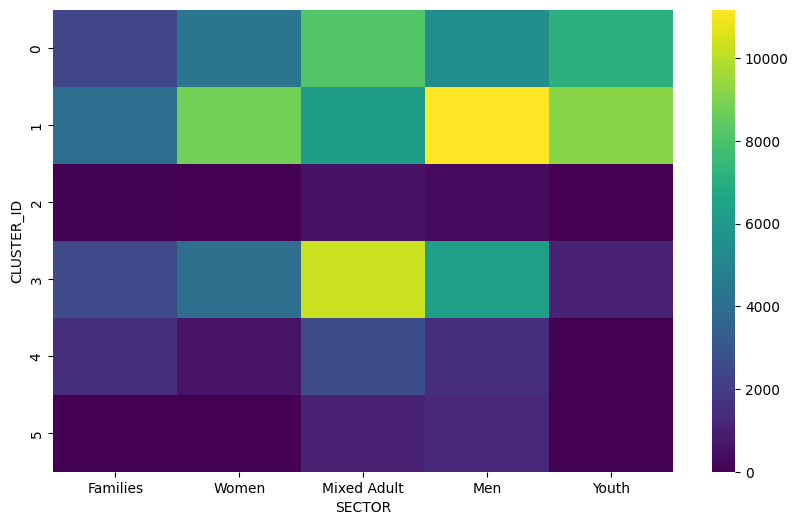

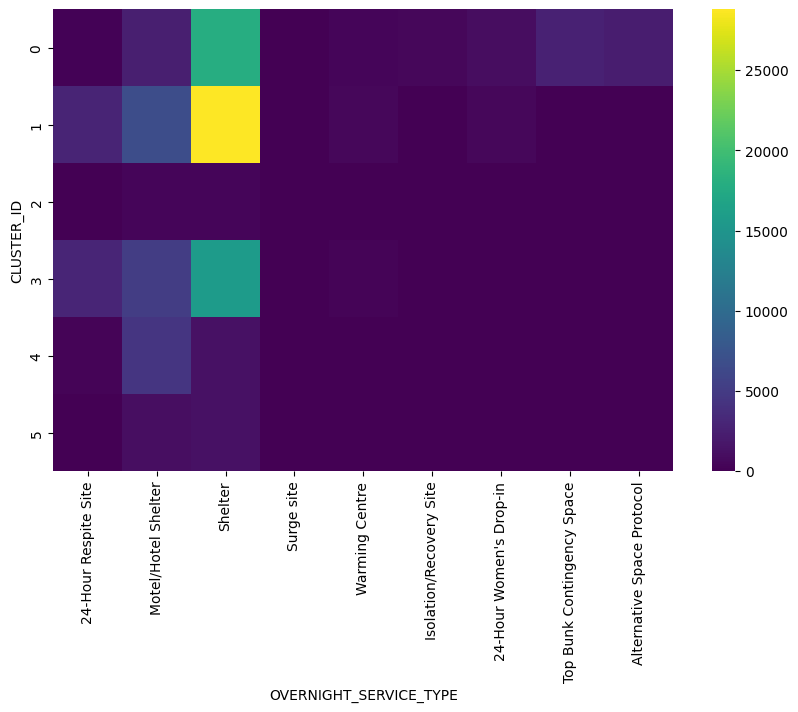

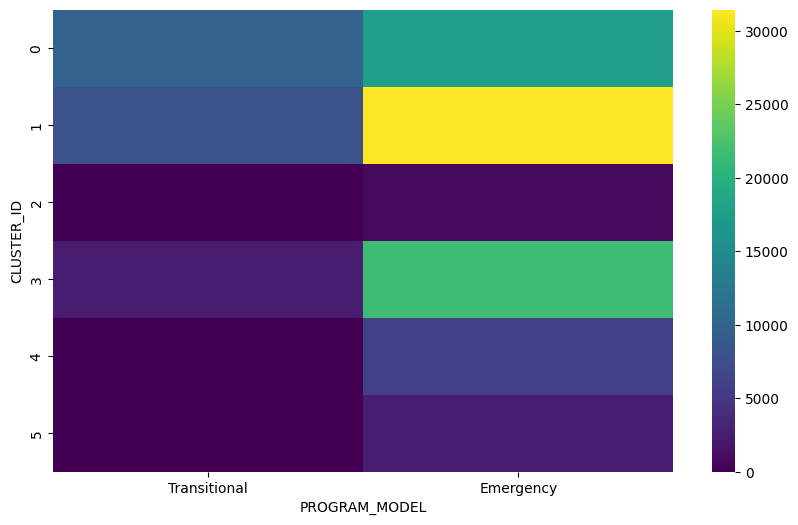

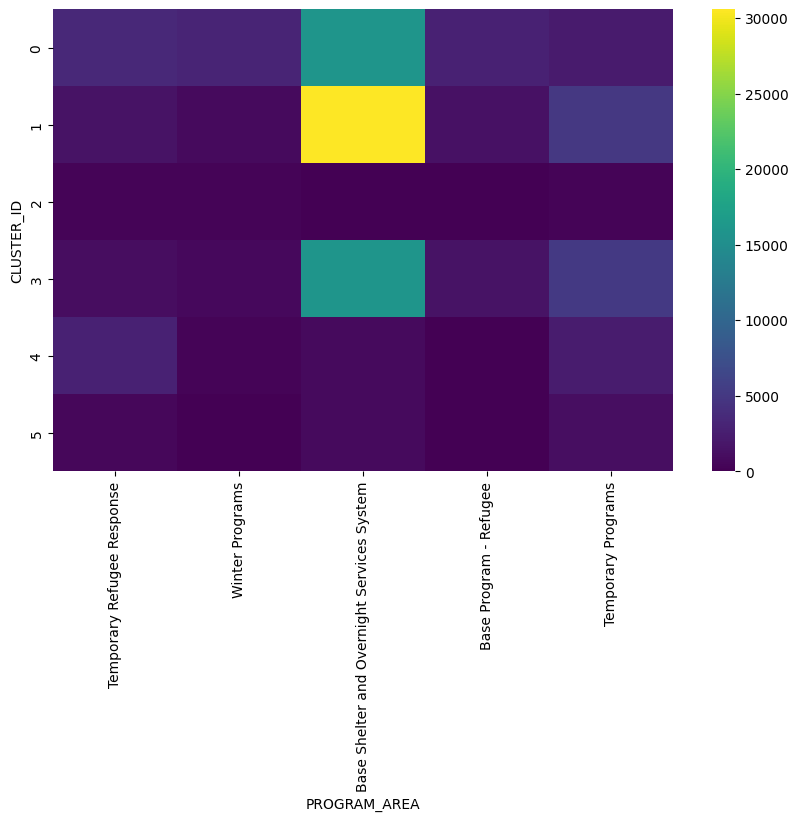

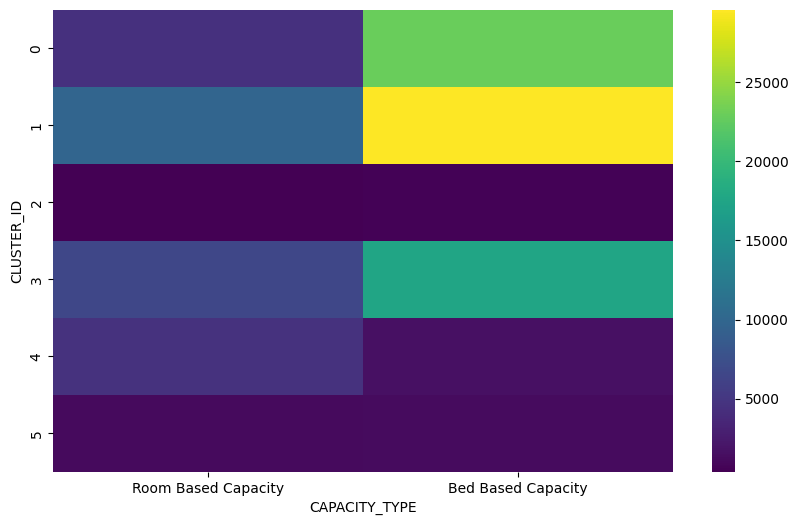

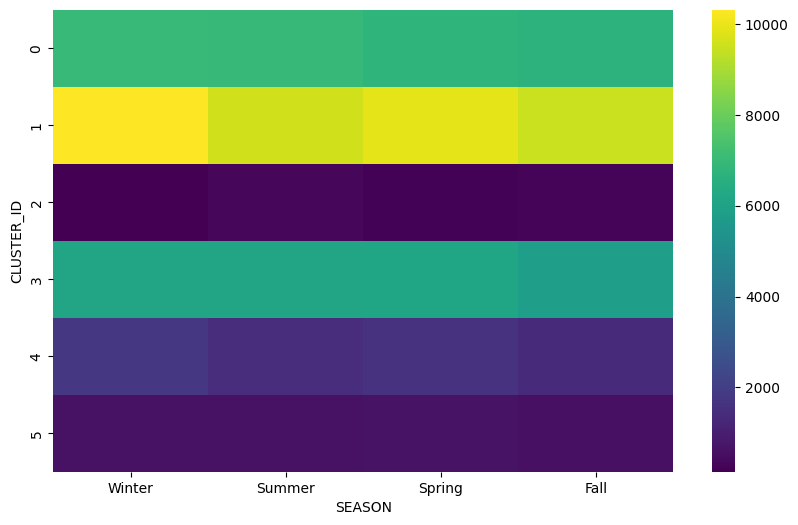

In [895]:
categorical_features = ["SECTOR", "OVERNIGHT_SERVICE_TYPE", "PROGRAM_MODEL", "PROGRAM_AREA", "CAPACITY_TYPE", "SEASON"]

for feature in categorical_features:
    counts_df = get_cluster_counts_df(feature)
    plot_heatmap(counts_df, feature)

**Interpretation**

- `CLUSTER_ID` 0 dominates all heatmaps: most shelters have a small capacity
- Most shelters used a bed-based capacity system

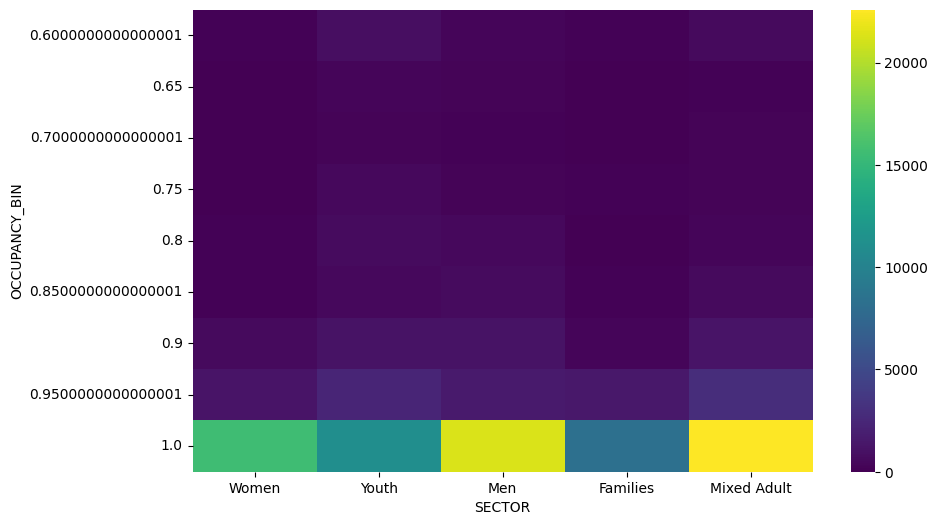

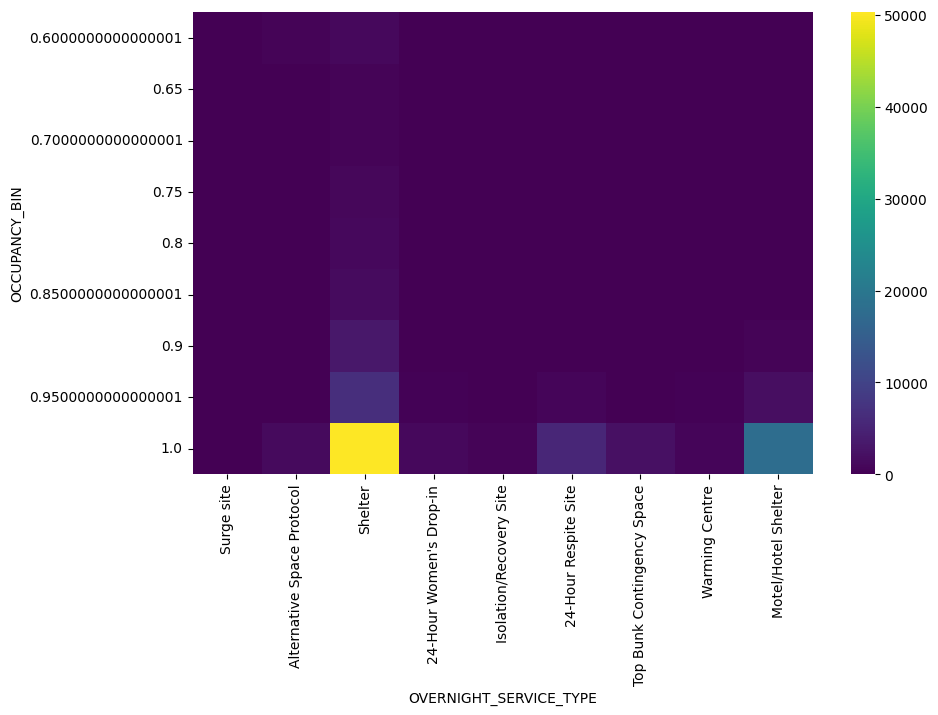

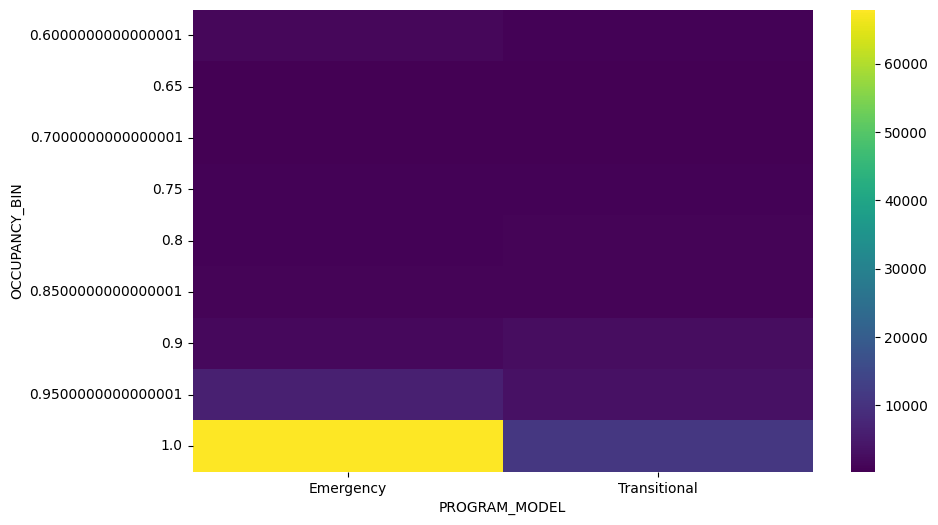

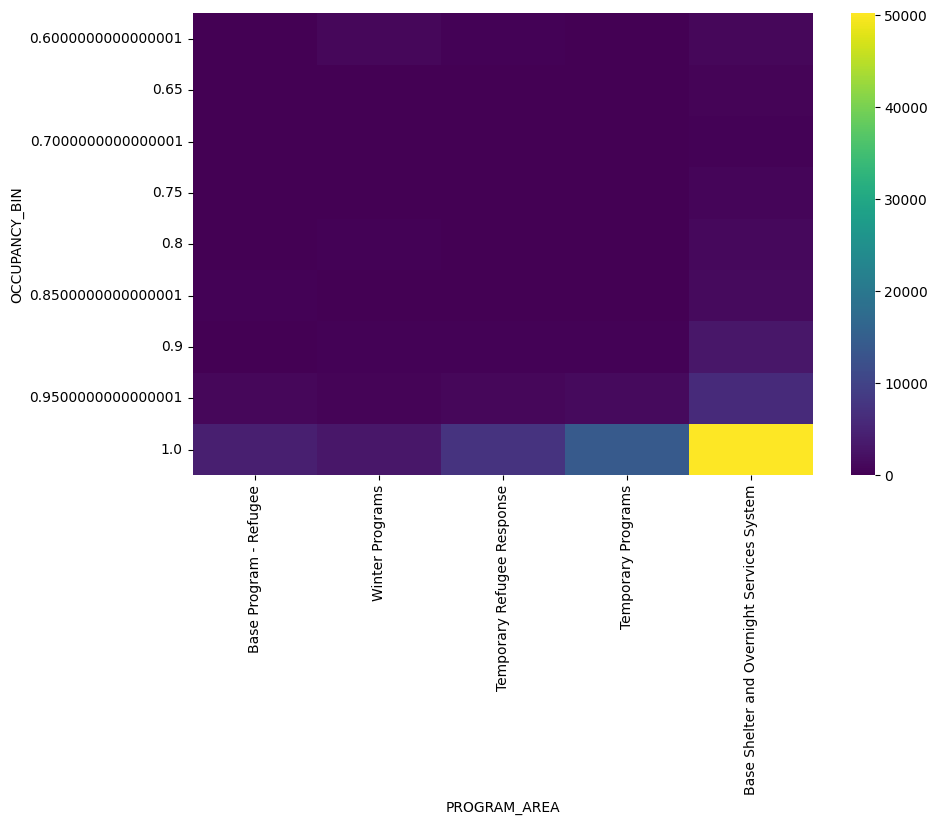

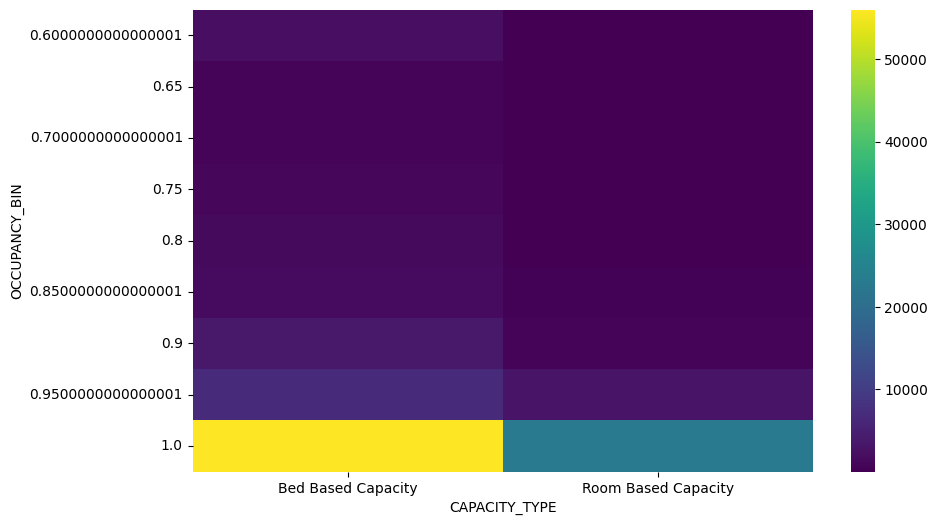

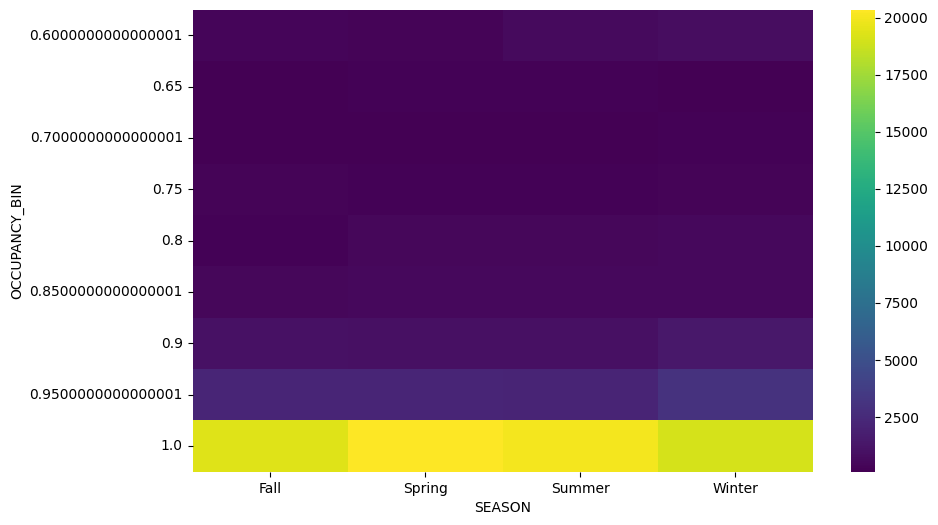

In [896]:
for feature in categorical_features:
    counts_df = get_rates_counts_df(feature)
    plot_heatmap(counts_df, feature, y="OCCUPANCY_BIN")